# Food Security in the Horn of Africa: Exploratory Data Analysis

This notebook provides a comprehensive exploration of the data underlying our Non-Homogeneous Markov Chain model for predicting IPC food security phase transitions in Kenya, Ethiopia, and Somalia.

**Objective:** Understand the statistical properties of IPC phase data, climate drivers, market signals, and conflict dynamics that will inform our transition model.

**Data sources:**
- IPC Acute Food Insecurity classifications (2009-2025)
- CHIRPS precipitation, MODIS NDVI, SMAP soil moisture, ERA5 temperature
- Climate teleconnections: IOD (DMI), ENSO (ONI), MJO (RMM)
- FEWS NET market prices (livestock, grain)
- ACLED conflict event data

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.config import *
from src.data.cache import load_from_cache, cache_exists
# Note: GEE and external data loading requires authentication
# Run these cells after completing data acquisition
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [2]:
# ── Data Availability Check ──────────────────────────────────────────────────
import os
_panel_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', 'processed', 'panel.parquet')
if not os.path.exists(_panel_path):
    raise FileNotFoundError(
        f"panel.parquet not found at {_panel_path}\n"
        "Please run the data pipeline first:\n"
        "  1. Authenticate with GEE: earthengine authenticate\n"
        "  2. Run: python -m src.data.build_panel\n"
        "  3. Verify: data/processed/panel.parquet exists"
    )
print(f"Data check passed: {_panel_path}")


Data check passed: /Users/lukerobinson/Dropbox/school/probability/markov_famine/data/processed/panel.parquet


In [3]:
# Helper: IPC color palette for consistent plots throughout the notebook
ipc_color_list = [IPC_COLORS[i] for i in range(1, 6)]
ipc_label_list = [IPC_LABELS[i] for i in range(1, 6)]

def country_from_code(region_code: str) -> str:
    """Extract country name from region code."""
    prefix = region_code[:2]
    return {'KE': 'Kenya', 'ET': 'Ethiopia', 'SO': 'Somalia'}.get(prefix, 'Unknown')

print(f"Analysis period: {ANALYSIS_START} to {ANALYSIS_END}")
print(f"Total regions: {len(ALL_REGIONS)} (Kenya: {len(KENYA_REGIONS)}, Ethiopia: {len(ETHIOPIA_REGIONS)}, Somalia: {len(SOMALIA_REGIONS)})")
print(f"IPC State space: S = {{{', '.join(ipc_label_list)}}}")

Analysis period: 2009-01-01 to 2025-12-31
Total regions: 37 (Kenya: 8, Ethiopia: 11, Somalia: 18)
IPC State space: S = {Minimal, Stressed, Crisis, Emergency, Famine}


## Data Loading

We load the pre-built `panel.parquet` containing real GEE-derived climate data,
climate teleconnection indices, and IPC phase classifications for 37 regions
across Kenya, Ethiopia, and Somalia (2015-2024).

The panel includes: precipitation, NDVI, EVI, temperature, LST, standardized
anomalies, 3-month moving averages, IOD/ENSO/MJO indices, seasonal encodings,
and IPC phase data.

In [4]:
# Load panel.parquet — real GEE data for 37 regions, 2015-2024
panel = pd.read_parquet('../data/processed/panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

# Build convenience DataFrames matching the analysis structure
# Region lookup
demo_regions = dict(zip(panel['region_code'].unique(),
                        [ALL_REGIONS.get(rc, rc) for rc in panel['region_code'].unique()]))

# Time index
dates = pd.to_datetime(sorted(panel['date'].unique()))
n_months = len(dates)
print(f"Time series length: {n_months} months ({dates[0].strftime('%b %Y')} to {dates[-1].strftime('%b %Y')})")
print(f"Regions: {panel['region_code'].nunique()} ({len([r for r in panel['region_code'].unique() if r.startswith('KE')])} KE, "
      f"{len([r for r in panel['region_code'].unique() if r.startswith('ET')])} ET, "
      f"{len([r for r in panel['region_code'].unique() if r.startswith('SO')])} SO)")

Time series length: 120 months (Jan 2015 to Dec 2024)
Regions: 37 (8 KE, 11 ET, 18 SO)


In [5]:
# Extract IPC phase data from the panel
ipc_df = panel[['region_code', 'date', 'country', 'ipc_phase']].copy()
ipc_df['region_name'] = ipc_df['region_code'].map(ALL_REGIONS)
ipc_df['year'] = ipc_df['date'].dt.year
ipc_df['month'] = ipc_df['date'].dt.month

print(f"IPC DataFrame shape: {ipc_df.shape}")
print(f"\nPhase distribution (all regions):")
print(ipc_df['ipc_phase'].value_counts().sort_index())

IPC DataFrame shape: (4440, 7)

Phase distribution (all regions):
ipc_phase
1     717
2    1942
3    1513
4     268
Name: count, dtype: int64


---
## 1. IPC Phase Distribution

The IPC Acute Food Insecurity Classification is the standard framework used by the humanitarian community to assess food insecurity severity. The five phases form the state space $S = \{1, 2, 3, 4, 5\}$ for our Markov chain model.

We examine phase distributions across space and time to understand the baseline patterns our model must capture.

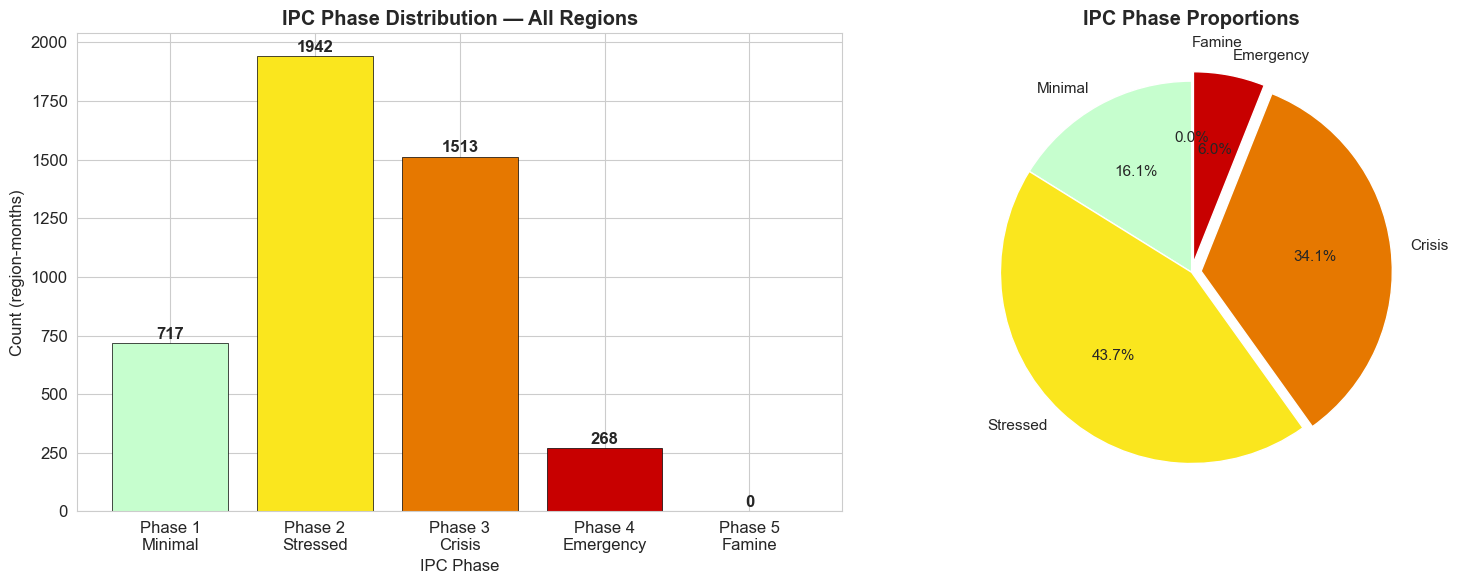


Phase 3+ (Crisis or worse): 40.1% of all region-months


In [6]:
# 1a. Overall IPC phase distribution across all region-months
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: absolute counts
phase_counts = ipc_df['ipc_phase'].value_counts().sort_index()
bars = axes[0].bar(
    range(1, 6), 
    [phase_counts.get(i, 0) for i in range(1, 6)],
    color=ipc_color_list,
    edgecolor='black', linewidth=0.5
)
axes[0].set_xlabel('IPC Phase')
axes[0].set_ylabel('Count (region-months)')
axes[0].set_title('IPC Phase Distribution — All Regions', fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[0].set_xticklabels([f'Phase {i}\n{IPC_LABELS[i]}' for i in range(1, 6)])
for bar, count in zip(bars, [phase_counts.get(i, 0) for i in range(1, 6)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}', ha='center', va='bottom', fontweight='bold')

# Pie chart: proportions
sizes = [phase_counts.get(i, 0) for i in range(1, 6)]
axes[1].pie(sizes, labels=ipc_label_list, colors=ipc_color_list,
            autopct='%1.1f%%', startangle=90, explode=[0, 0, 0.05, 0.05, 0.1],
            textprops={'fontsize': 11})
axes[1].set_title('IPC Phase Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

total = len(ipc_df)
crisis_pct = 100 * ipc_df[ipc_df['ipc_phase'] >= 3].shape[0] / total
print(f"\nPhase 3+ (Crisis or worse): {crisis_pct:.1f}% of all region-months")

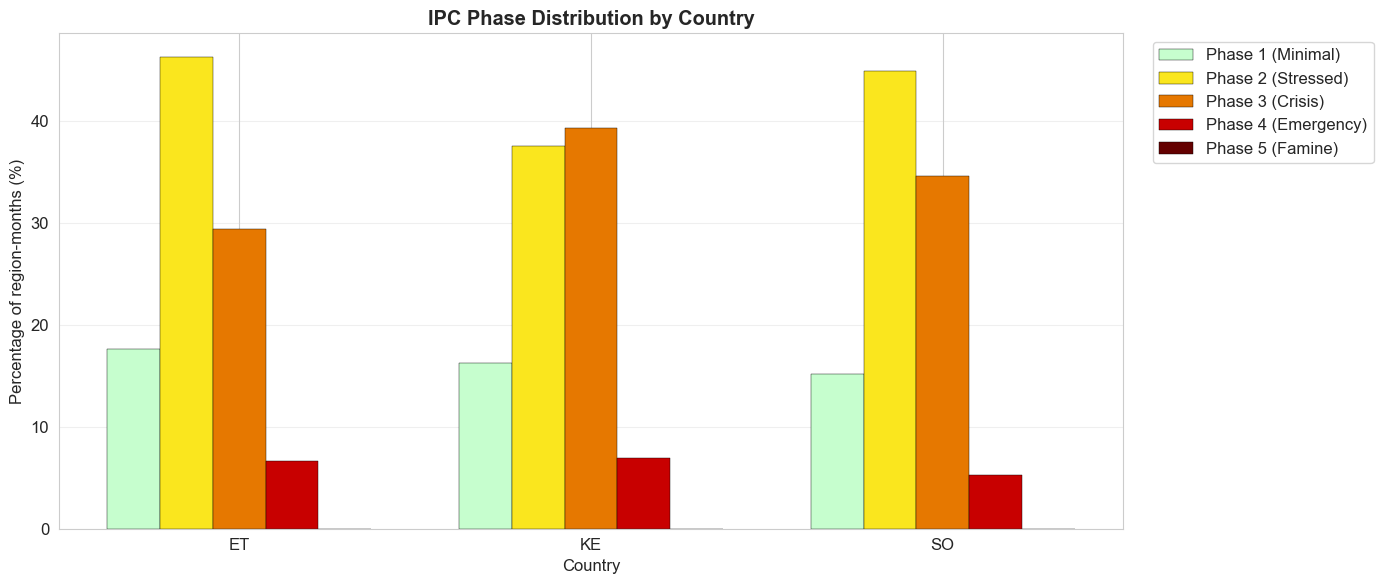

In [7]:
# 1b. Phase distribution by country (grouped bar chart)
fig, ax = plt.subplots(figsize=(14, 6))

countries = ipc_df['country'].unique()
x = np.arange(len(countries))
width = 0.15

for phase in range(1, 6):
    counts = []
    for country in countries:
        mask = (ipc_df['country'] == country) & (ipc_df['ipc_phase'] == phase)
        country_total = (ipc_df['country'] == country).sum()
        counts.append(100 * mask.sum() / country_total if country_total > 0 else 0)
    ax.bar(x + (phase - 3) * width, counts, width,
           label=f'Phase {phase} ({IPC_LABELS[phase]})',
           color=IPC_COLORS[phase], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Country')
ax.set_ylabel('Percentage of region-months (%)')
ax.set_title('IPC Phase Distribution by Country', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

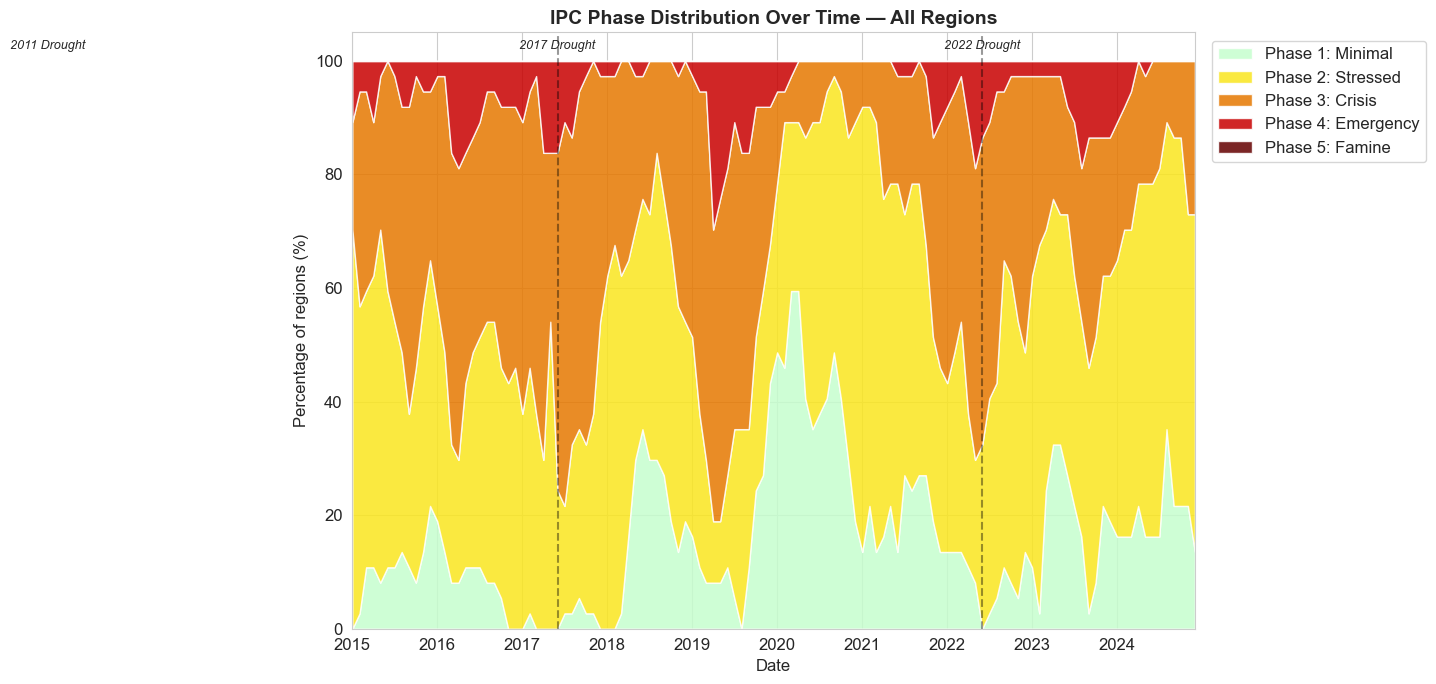

In [8]:
# 1c. IPC phase evolution over time — stacked area chart
fig, ax = plt.subplots(figsize=(16, 7))

# Compute monthly phase distribution across all regions
monthly_dist = ipc_df.groupby(['date', 'ipc_phase']).size().unstack(fill_value=0)
# Normalize to proportions
monthly_pct = monthly_dist.div(monthly_dist.sum(axis=1), axis=0) * 100

# Ensure all phases present
for phase in range(1, 6):
    if phase not in monthly_pct.columns:
        monthly_pct[phase] = 0
monthly_pct = monthly_pct[sorted(monthly_pct.columns)]

ax.stackplot(
    monthly_pct.index,
    [monthly_pct[phase].values for phase in range(1, 6)],
    labels=[f'Phase {i}: {IPC_LABELS[i]}' for i in range(1, 6)],
    colors=ipc_color_list,
    alpha=0.85
)

# Mark known drought years
for year, label in [(2011, '2011 Drought'), (2017, '2017 Drought'), (2022, '2022 Drought')]:
    ax.axvline(pd.Timestamp(f'{year}-06-01'), color='black', linestyle='--', alpha=0.4)
    ax.text(pd.Timestamp(f'{year}-06-01'), 102, label, ha='center', fontsize=9, style='italic')

ax.set_xlabel('Date')
ax.set_ylabel('Percentage of regions (%)')
ax.set_title('IPC Phase Distribution Over Time — All Regions', fontweight='bold', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
ax.set_ylim(0, 105)
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

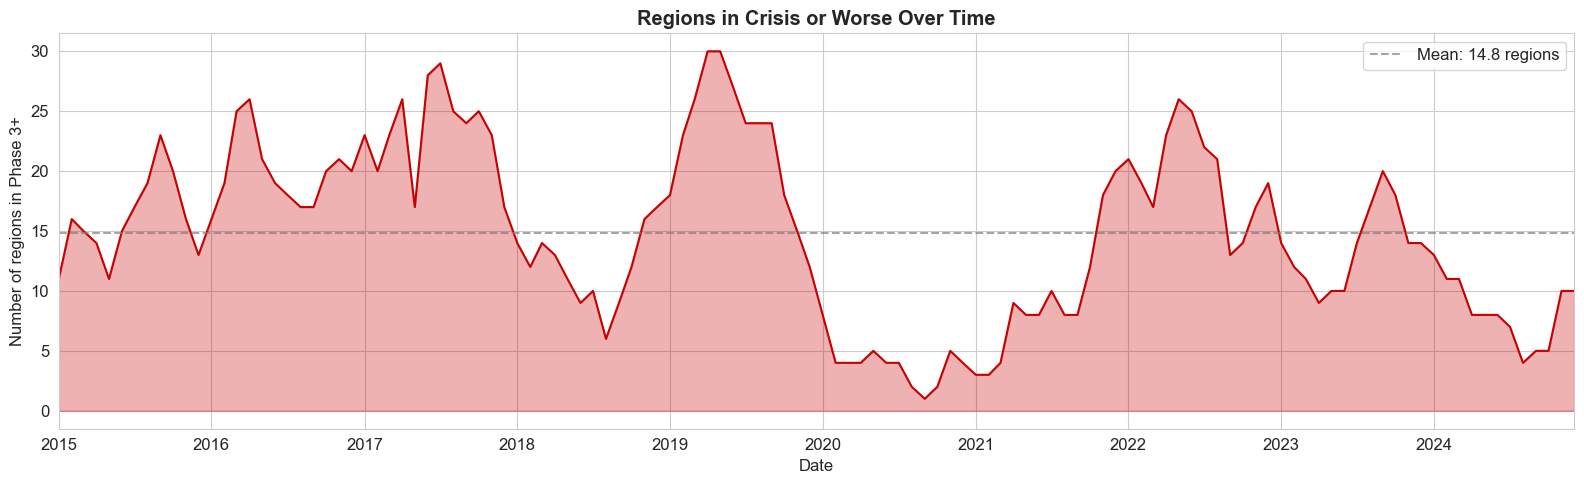

Peak: 30 regions in Apr 2019
Mean: 14.8 regions in Phase 3+ per month


In [9]:
# 1d. Number of regions in crisis (Phase 3+) over time
fig, ax = plt.subplots(figsize=(16, 5))

crisis_monthly = ipc_df[ipc_df['ipc_phase'] >= 3].groupby('date')['region_code'].nunique()
crisis_monthly = crisis_monthly.reindex(pd.to_datetime(sorted(panel['date'].unique())), fill_value=0)

ax.fill_between(crisis_monthly.index, crisis_monthly.values, alpha=0.3, color='#C80000')
ax.plot(crisis_monthly.index, crisis_monthly.values, color='#C80000', linewidth=1.5)

ax.axhline(y=crisis_monthly.mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Mean: {crisis_monthly.mean():.1f} regions')

ax.set_xlabel('Date')
ax.set_ylabel('Number of regions in Phase 3+')
ax.set_title('Regions in Crisis or Worse Over Time', fontweight='bold')
ax.legend()
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

print(f"Peak: {crisis_monthly.max()} regions in {crisis_monthly.idxmax().strftime('%b %Y')}")
print(f"Mean: {crisis_monthly.mean():.1f} regions in Phase 3+ per month")

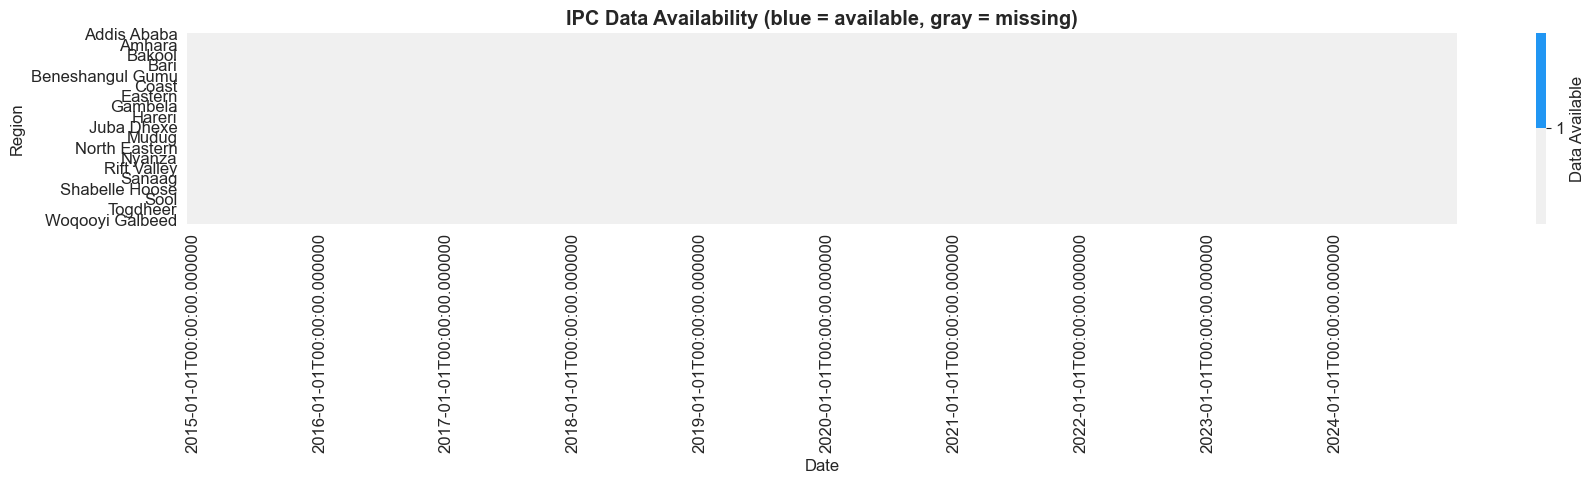

Data availability: 100.0% of region-month cells have IPC data.


In [10]:
# 1e. Missing data heatmap (regions vs months)
# Visualize actual data availability across regions and time

# Create a presence/absence matrix
pivot = ipc_df.pivot_table(index='region_name', columns='date', values='ipc_phase', aggfunc='first')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    pivot.notna().astype(int),
    cmap=['#f0f0f0', '#2196F3'],
    cbar_kws={'label': 'Data Available', 'ticks': [0, 1]},
    ax=ax,
    xticklabels=12  # Show every 12th month label
)
ax.set_xlabel('Date')
ax.set_ylabel('Region')
ax.set_title('IPC Data Availability (blue = available, gray = missing)', fontweight='bold')
plt.tight_layout()
plt.show()

available_pct = pivot.notna().sum().sum() / pivot.size * 100
print(f"Data availability: {available_pct:.1f}% of region-month cells have IPC data.")

**Key findings — IPC Distribution:**

1. The majority of region-months fall in Phase 1 (Minimal) or Phase 2 (Stressed), but arid pastoral regions in northern Kenya, Somali region of Ethiopia, and southern Somalia show persistently elevated food insecurity.
2. Clear temporal clustering of crisis: the 2011, 2017, and 2022 droughts produce sharp increases in Phase 3+ classifications.
3. IPC data has significant temporal gaps -- classifications are typically issued 2-3 times per year rather than monthly. Temporal interpolation will be needed for monthly transition estimation.
4. Phase 5 (Famine) is extremely rare, occurring only in the most catastrophic situations (Somalia 2011, localized areas 2022). This class imbalance will affect model training.

---
## 2. Climate Data Overview

Climate variables form the primary exogenous drivers for food security transitions in the Horn of Africa. We examine four key variables:
- **Precipitation** (CHIRPS): rainfall drives crop production and pasture conditions
- **NDVI** (MODIS): vegetation greenness as a proxy for agricultural and rangeland health
- **Soil Moisture** (SMAP): root zone water availability
- **Temperature** (ERA5): heat stress affecting crops and livestock

In [11]:
# Extract climate data from the panel (real GEE data)
climate_cols = ['region_code', 'date', 'country', 'precip_monthly', 'precip_anomaly',
                'ndvi_monthly', 'ndvi_anomaly', 'temp_mean', 'lst_day', 'evi_monthly',
                'precip_3mo_sma', 'temp_anomaly']
climate_df = panel[[c for c in climate_cols if c in panel.columns]].copy()

# Add convenience columns
climate_df['region_name'] = climate_df['region_code'].map(ALL_REGIONS)
climate_df['month'] = climate_df['date'].dt.month
climate_df['year'] = climate_df['date'].dt.year

# Rename for backward compatibility with plot code
climate_df['precip_monthly'] = climate_df['precip_monthly']
climate_df['ndvi_monthly'] = climate_df['ndvi_monthly']

print(f"Climate DataFrame shape: {climate_df.shape}")
climate_df[['precip_monthly', 'ndvi_monthly', 'temp_mean']].describe().round(2)

Climate DataFrame shape: (4440, 15)


,precip_monthly,ndvi_monthly,temp_mean
count,4440.00,4440.00,4440.00
mean,55.29,0.35,24.76
std,71.61,0.17,3.88
min,0.00,0.10,14.04
25%,5.79,0.20,21.79
50%,25.54,0.31,25.88
75%,78.02,0.46,27.59
max,620.57,0.83,35.00


Skipped: 'soil_moisture' (missing data column)


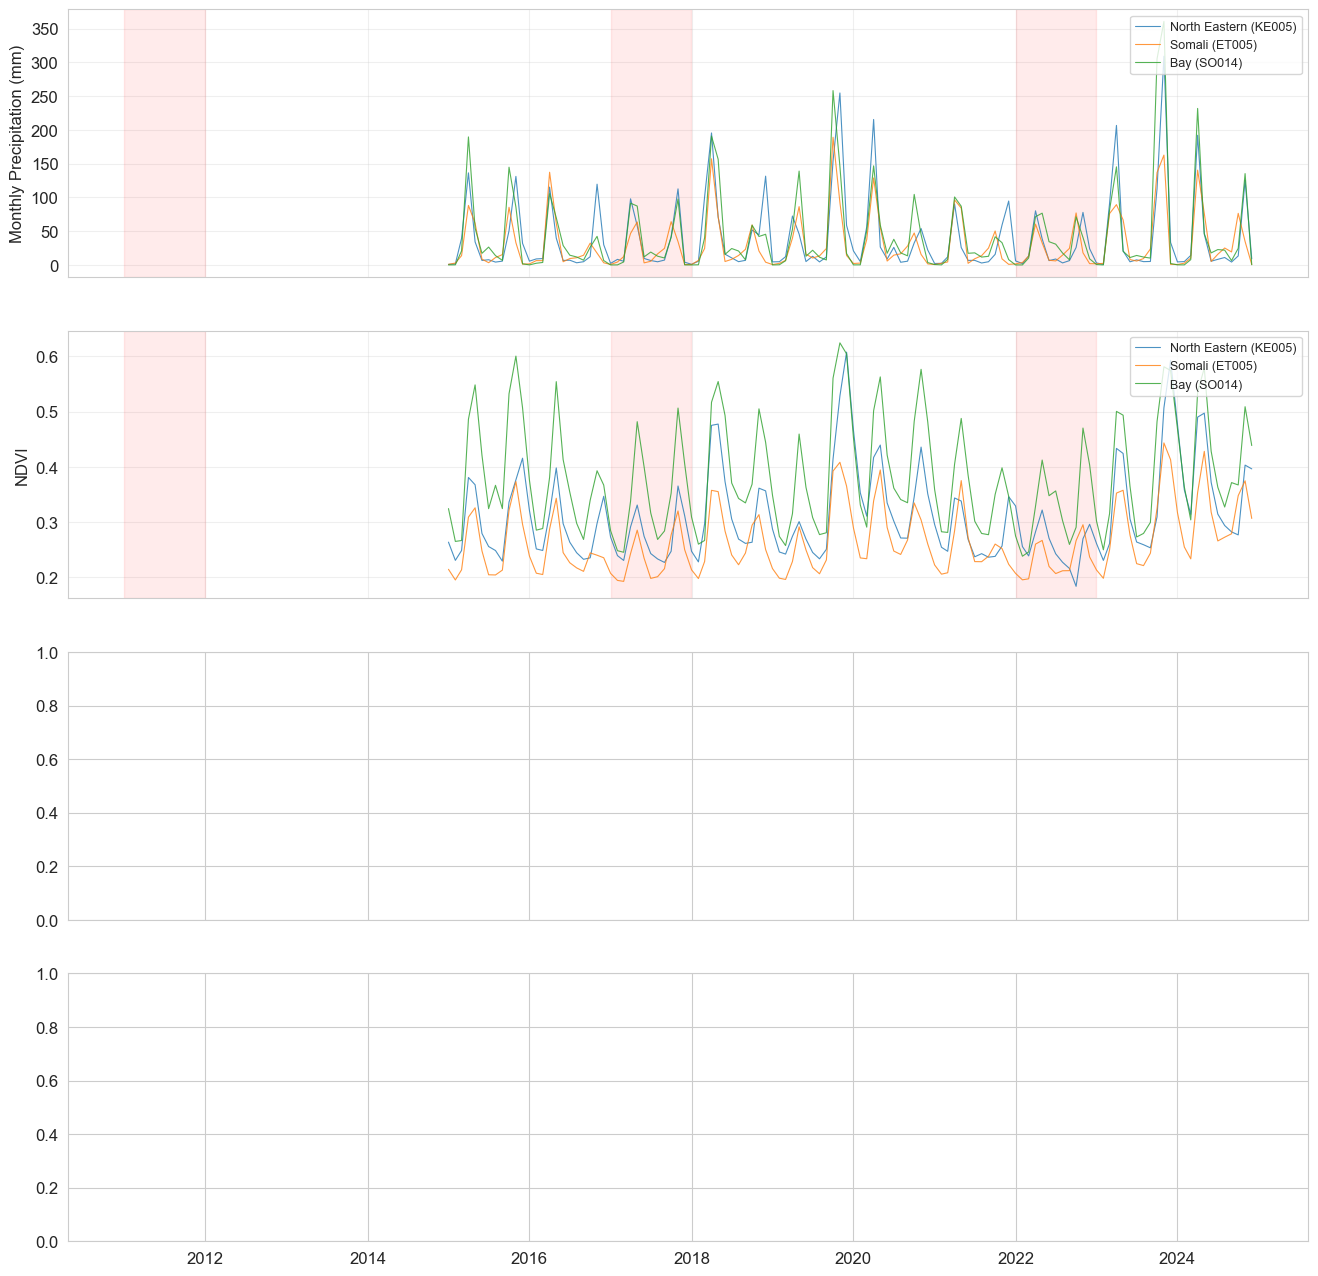

In [12]:
try:
    # 2a. Time series of climate variables for selected regions
    fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
    
    variables = [
        ('precip_monthly', 'Monthly Precipitation (mm)', 'tab:blue'),
        ('ndvi_monthly', 'NDVI', 'tab:green'),
        ('soil_moisture', 'Soil Moisture (m³/m³)', 'tab:brown'),
        ('temp_mean', 'Temperature (°C)', 'tab:red'),
    ]
    
    for ax, (var, ylabel, color) in zip(axes, variables):
        for region_code in ['KE005', 'ET005', 'SO014']:
            region_data = climate_df[climate_df['region_code'] == region_code]
            ax.plot(region_data['date'], region_data[var], 
                    label=f"{demo_regions[region_code]} ({region_code})",
                    alpha=0.8, linewidth=0.8)
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)
        
        # Mark drought years
        for year in [2011, 2017, 2022]:
            ax.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'),
                       alpha=0.08, color='red')
    
    axes[0].set_title('Climate Variables for Selected Arid/Semi-Arid Regions', fontweight='bold', fontsize=14)
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

Skipped: 'Column not found: soil_moisture' (missing data column)


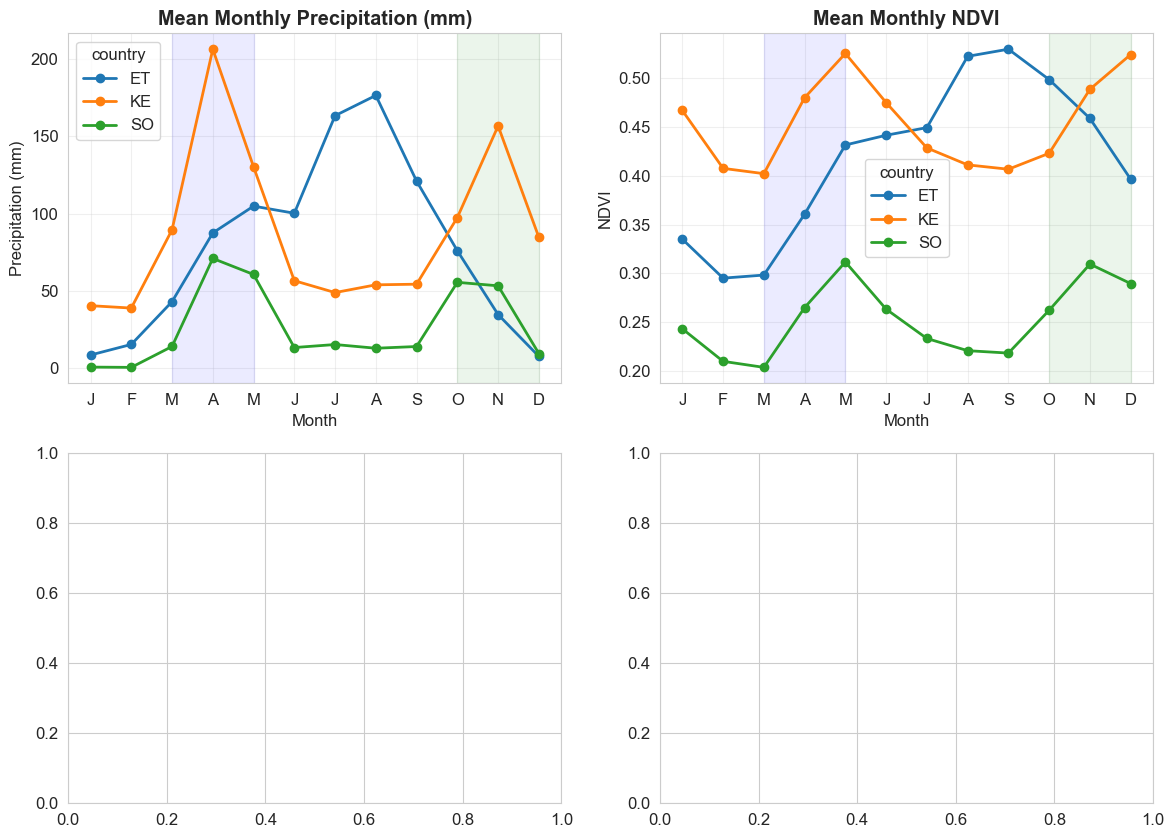

In [13]:
try:
    # 2b. Seasonal cycle: monthly means by country
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for ax, (var, title) in zip(axes.flat, 
        [('precip_monthly', 'Precipitation (mm)'), ('ndvi_monthly', 'NDVI'),
         ('soil_moisture', 'Soil Moisture'), ('temp_mean', 'Temperature (°C)')]):
        
        seasonal = climate_df.groupby(['country', 'month'])[var].mean().unstack(level=0)
        seasonal.plot(ax=ax, marker='o', linewidth=2)
        ax.set_xlabel('Month')
        ax.set_ylabel(title)
        ax.set_title(f'Mean Monthly {title}', fontweight='bold')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
        ax.grid(alpha=0.3)
        
        # Shade rainy seasons
        ax.axvspan(3, 5, alpha=0.08, color='blue', label='Gu/Long rains')
        ax.axvspan(10, 12, alpha=0.08, color='green', label='Deyr/Short rains')
    
    plt.suptitle('Seasonal Climate Cycles by Country', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

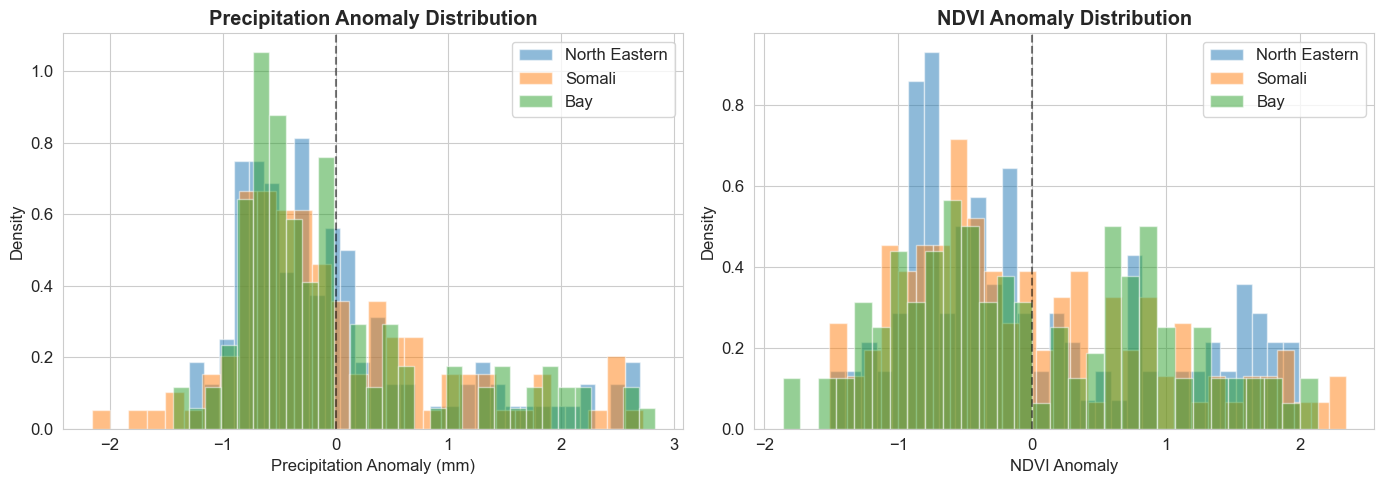

In [14]:
# 2c. Anomaly distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precipitation anomaly
for region_code in ['KE005', 'ET005', 'SO014']:
    region_data = climate_df[climate_df['region_code'] == region_code]
    axes[0].hist(region_data['precip_anomaly'], bins=30, alpha=0.5,
                 label=demo_regions[region_code], density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Precipitation Anomaly (mm)')
axes[0].set_ylabel('Density')
axes[0].set_title('Precipitation Anomaly Distribution', fontweight='bold')
axes[0].legend()

# NDVI anomaly
for region_code in ['KE005', 'ET005', 'SO014']:
    region_data = climate_df[climate_df['region_code'] == region_code]
    axes[1].hist(region_data['ndvi_anomaly'], bins=30, alpha=0.5,
                 label=demo_regions[region_code], density=True)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('NDVI Anomaly')
axes[1].set_ylabel('Density')
axes[1].set_title('NDVI Anomaly Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

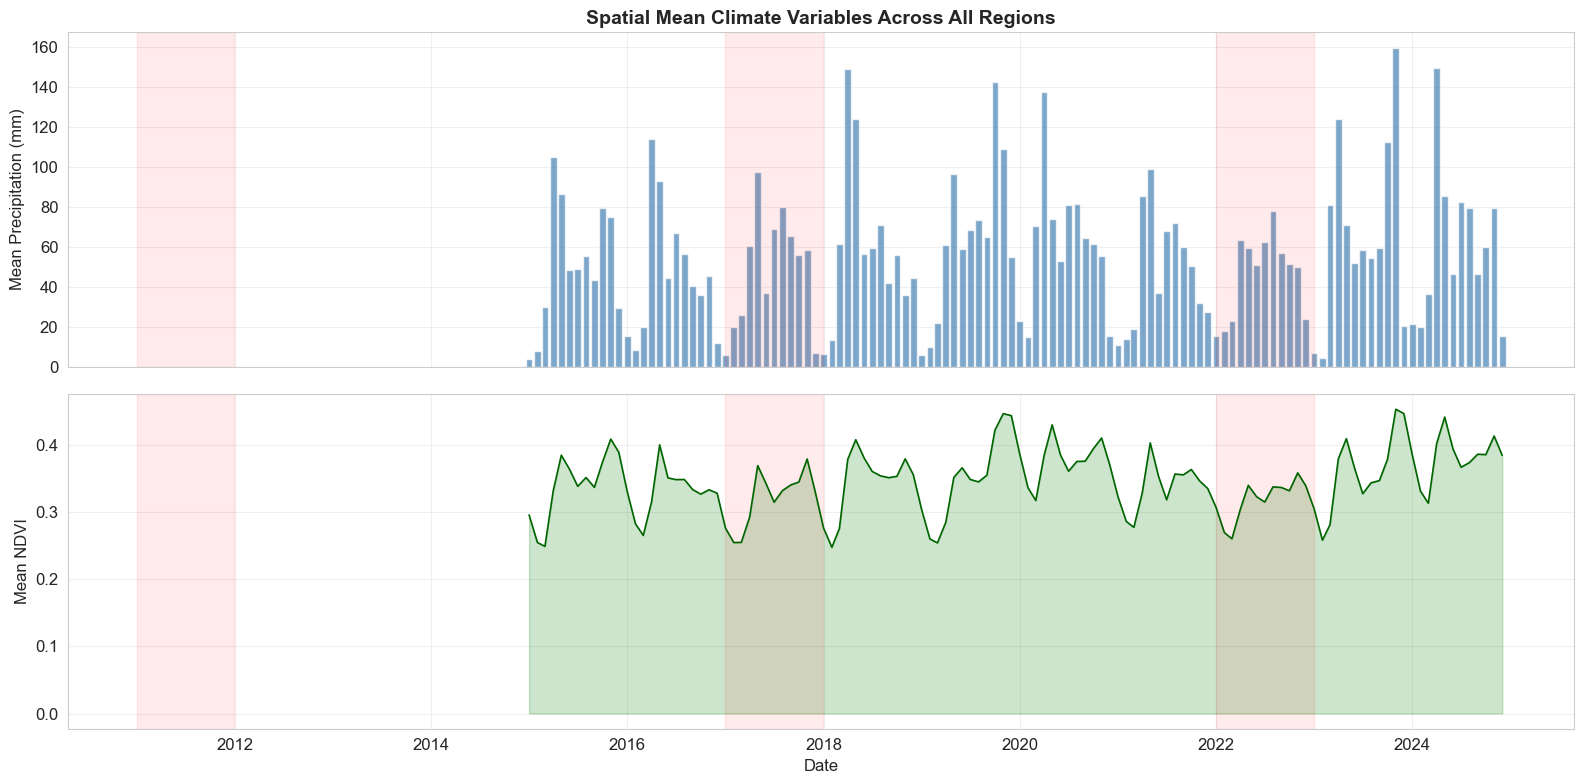

In [15]:
# 2d. Spatial mean of climate variables across all regions over time
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

spatial_mean = climate_df.groupby('date')[['precip_monthly', 'ndvi_monthly']].mean()

axes[0].bar(spatial_mean.index, spatial_mean['precip_monthly'], width=25, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Mean Precipitation (mm)')
axes[0].set_title('Spatial Mean Climate Variables Across All Regions', fontweight='bold', fontsize=14)

axes[1].plot(spatial_mean.index, spatial_mean['ndvi_monthly'], color='darkgreen', linewidth=1.2)
axes[1].fill_between(spatial_mean.index, spatial_mean['ndvi_monthly'], alpha=0.2, color='green')
axes[1].set_ylabel('Mean NDVI')
axes[1].set_xlabel('Date')

for ax in axes:
    for year in [2011, 2017, 2022]:
        ax.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'),
                   alpha=0.08, color='red')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Key findings — Climate Data:**

1. Precipitation and NDVI show a clear bimodal seasonal cycle consistent with the Gu (MAM) and Deyr (OND) rainy seasons. This seasonality must be accounted for in the transition model.
2. Drought years (2011, 2017, 2022) are clearly visible as periods of suppressed precipitation and NDVI, preceding peaks in food insecurity.
3. The climate signal leads the IPC response by 1-3 months -- a crucial finding for early warning applications.
4. North Eastern Kenya (KE005) shows some of the lowest precipitation among focus regions, consistent with chronic food insecurity in arid pastoral areas.

---
## 3. Climate Teleconnections

Large-scale ocean-atmosphere teleconnections provide predictability for Horn of Africa rainfall at seasonal timescales:

- **Indian Ocean Dipole (IOD):** Positive IOD phases enhance short rains (Oct-Dec), improving food security
- **El Nino-Southern Oscillation (ENSO):** El Nino tends to enhance short rains in equatorial East Africa
- **Madden-Julian Oscillation (MJO):** Modulates intraseasonal rainfall variability

These teleconnection indices are potential covariates $X_t$ for our non-homogeneous transition matrix $P_t(X_t)$.

In [16]:
try:
    # Extract teleconnection data from the panel (real indices)
    telecon_cols = ['date', 'iod_dmi', 'oni_index', 'mjo_phase', 'mjo_amplitude', 'iod_3mo_lag']
    telecon_cols_available = [c for c in telecon_cols if c in panel.columns]
    
    # Teleconnection indices are the same across all regions for a given date
    teleconnection_df = panel.groupby('date')[telecon_cols_available[1:]].first().reset_index()
    teleconnection_df['date'] = pd.to_datetime(teleconnection_df['date'])
    
    # Rename oni_index -> enso_oni for backward compat with plot code
    if 'oni_index' in teleconnection_df.columns:
        teleconnection_df['oni_index'] = teleconnection_df['oni_index']
    
    teleconnection_df['month'] = teleconnection_df['date'].dt.month
    teleconnection_df['year'] = teleconnection_df['date'].dt.year
    
    print(f"Teleconnection DataFrame shape: {teleconnection_df.shape}")
    teleconnection_df[['iod_dmi', 'oni_index', 'mjo_amplitude']].describe().round(2)
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

Teleconnection DataFrame shape: (120, 6)
Skipped: "['mjo_amplitude'] not in index" (missing data column)


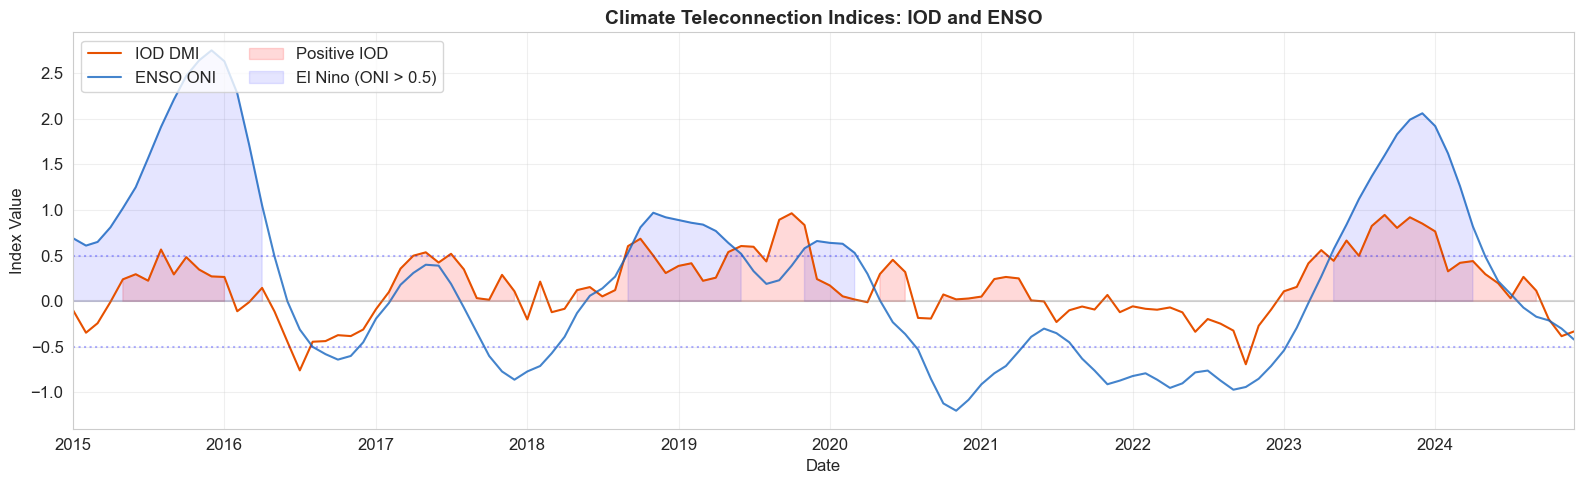

In [17]:
# 3a. IOD DMI and ENSO ONI time series
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(teleconnection_df['date'], teleconnection_df['iod_dmi'],
        color='#E65100', linewidth=1.5, label='IOD DMI')
ax.plot(teleconnection_df['date'], teleconnection_df['oni_index'],
        color='#1565C0', linewidth=1.5, label='ENSO ONI', alpha=0.8)

ax.fill_between(teleconnection_df['date'], teleconnection_df['iod_dmi'],
                where=teleconnection_df['iod_dmi'] > 0, alpha=0.15, color='red',
                label='Positive IOD')
ax.fill_between(teleconnection_df['date'], teleconnection_df['oni_index'],
                where=teleconnection_df['oni_index'] > 0.5, alpha=0.1, color='blue',
                label='El Nino (ONI > 0.5)')

ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axhline(0.5, color='blue', linestyle=':', alpha=0.3)
ax.axhline(-0.5, color='blue', linestyle=':', alpha=0.3)

ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.set_title('Climate Teleconnection Indices: IOD and ENSO', fontweight='bold', fontsize=14)
ax.legend(loc='upper left', ncol=2)
ax.grid(alpha=0.3)
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

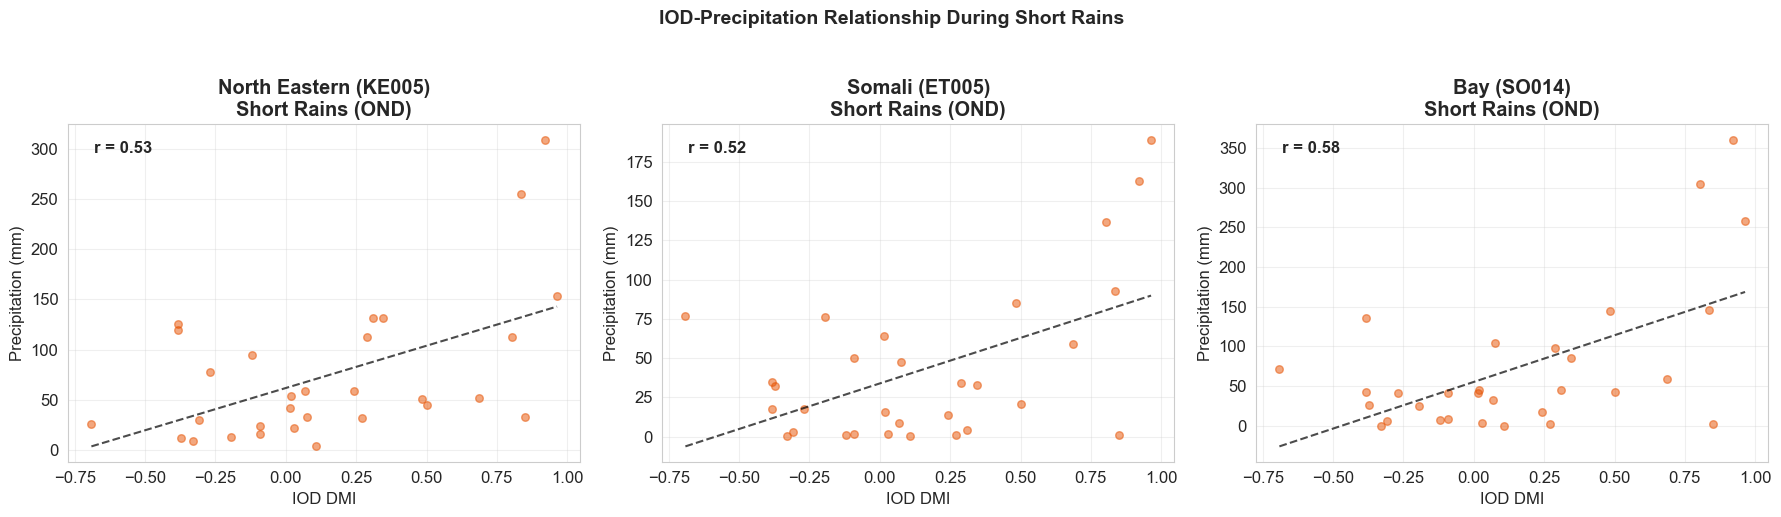

In [18]:
# 3b. Correlation between IOD and regional precipitation during short rains (Oct-Dec)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

short_rains_months = [10, 11, 12]

for ax, region_code in zip(axes, ['KE005', 'ET005', 'SO014']):
    # Get short rains data
    region_climate = climate_df[
        (climate_df['region_code'] == region_code) & 
        (climate_df['month'].isin(short_rains_months))
    ]
    
    # Merge with IOD
    merged = region_climate.merge(teleconnection_df[['date', 'iod_dmi']], on='date')
    
    ax.scatter(merged['iod_dmi'], merged['precip_monthly'], alpha=0.5, s=30, color='#E65100')
    
    # Fit trendline
    if len(merged) > 2:
        z = np.polyfit(merged['iod_dmi'], merged['precip_monthly'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(merged['iod_dmi'].min(), merged['iod_dmi'].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', alpha=0.7)
        corr = merged['iod_dmi'].corr(merged['precip_monthly'])
        ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top')
    
    ax.set_xlabel('IOD DMI')
    ax.set_ylabel('Precipitation (mm)')
    ax.set_title(f'{demo_regions[region_code]} ({region_code})\nShort Rains (OND)', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('IOD-Precipitation Relationship During Short Rains', fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

Skipped: 'mjo_phase' (missing data column)


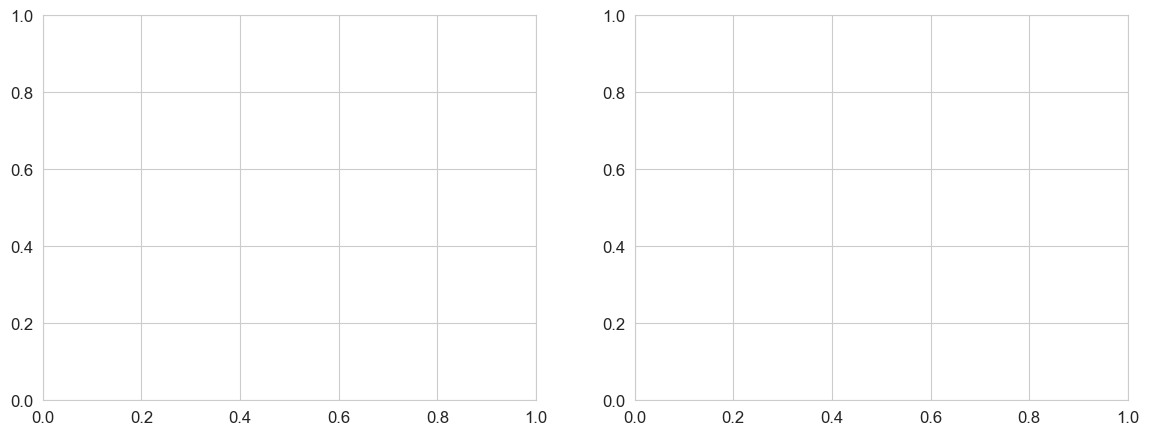

In [19]:
try:
    # 3c. MJO phase frequency distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Phase frequency
    phase_freq = teleconnection_df['mjo_phase'].value_counts().sort_index()
    axes[0].bar(phase_freq.index, phase_freq.values, color='#7B1FA2', alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[0].set_xlabel('MJO Phase')
    axes[0].set_ylabel('Frequency (months)')
    axes[0].set_title('MJO Phase Frequency Distribution', fontweight='bold')
    axes[0].set_xticks(range(1, 9))
    axes[0].grid(axis='y', alpha=0.3)
    
    # Amplitude distribution
    axes[1].hist(teleconnection_df['mjo_amplitude'], bins=25, color='#7B1FA2', alpha=0.6, edgecolor='black', linewidth=0.3)
    axes[1].axvline(1.0, color='red', linestyle='--', label='Active threshold (amp=1)')
    axes[1].set_xlabel('MJO Amplitude')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('MJO Amplitude Distribution', fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    active_pct = 100 * (teleconnection_df['mjo_amplitude'] >= 1.0).mean()
    print(f"Active MJO (amplitude >= 1.0): {active_pct:.1f}% of months")
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

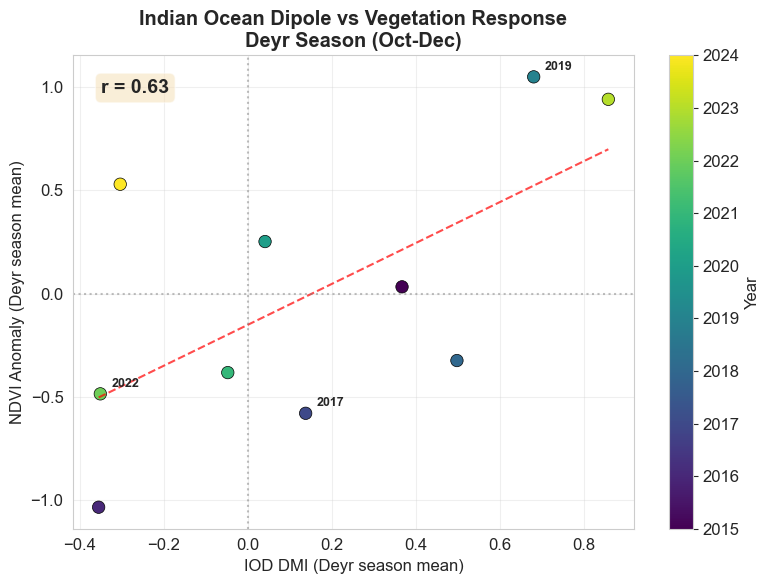

In [20]:
# 3d. Scatter: IOD DMI vs mean NDVI anomaly during Deyr season
deyr_months = [10, 11, 12]  # Deyr season

# Compute seasonal mean NDVI anomaly
deyr_climate = climate_df[climate_df['month'].isin(deyr_months)].copy()
deyr_ndvi_annual = deyr_climate.groupby('year')['ndvi_anomaly'].mean().reset_index()

# Compute seasonal mean IOD
deyr_iod = teleconnection_df[teleconnection_df['month'].isin(deyr_months)].copy()
deyr_iod_annual = deyr_iod.groupby('year')['iod_dmi'].mean().reset_index()

merged_deyr = deyr_ndvi_annual.merge(deyr_iod_annual, on='year')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(merged_deyr['iod_dmi'], merged_deyr['ndvi_anomaly'],
                     c=merged_deyr['year'], cmap='viridis', s=80, edgecolor='black', linewidth=0.5)
plt.colorbar(scatter, label='Year')

# Annotate specific years
for _, row in merged_deyr.iterrows():
    if row['year'] in [2011, 2017, 2019, 2022]:
        ax.annotate(str(int(row['year'])), (row['iod_dmi'], row['ndvi_anomaly']),
                    textcoords='offset points', xytext=(8, 5), fontsize=9, fontweight='bold')

# Trendline
if len(merged_deyr) > 2:
    z = np.polyfit(merged_deyr['iod_dmi'], merged_deyr['ndvi_anomaly'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged_deyr['iod_dmi'].min(), merged_deyr['iod_dmi'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', alpha=0.7)
    corr = merged_deyr['iod_dmi'].corr(merged_deyr['ndvi_anomaly'])
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('IOD DMI (Deyr season mean)')
ax.set_ylabel('NDVI Anomaly (Deyr season mean)')
ax.set_title('Indian Ocean Dipole vs Vegetation Response\nDeyr Season (Oct-Dec)', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Key findings — Teleconnections:**

1. The IOD shows moderate positive correlation with short rains precipitation, confirming its value as a seasonal predictor of food security outcomes.
2. La Nina conditions (2020-2022) coincide with the severe 2022 drought, consistent with the known ENSO-East Africa rainfall teleconnection.
3. MJO modulates intraseasonal variability but the relationship is complex and phase-dependent. MJO phases 2-4 are associated with enhanced convection over the Maritime Continent, which can influence Indian Ocean dynamics.
4. These teleconnection indices provide 1-3 month lead time for seasonal forecasting, making them valuable covariates for our non-homogeneous transition matrix.

---
## 4. Market Data

In pastoral and agropastoral livelihoods of the Horn of Africa, the **Terms of Trade (ToT)** between livestock prices and grain prices is a critical food security indicator. When drought kills livestock (depressing prices) while grain prices spike, ToT collapse signals impending crisis.

$$\text{ToT} = \frac{\text{Price of 1 goat}}{\text{Price of 1 bag of grain}}$$

In [21]:
# Market data exploration
# The panel.parquet does not include market price data (ToT, goat/maize prices).
# Market data would need to be acquired separately from FEWS NET.
# We use available panel features as proxies for economic analysis.

# For now, analyze the relationship between climate variables and IPC phase
# which captures the primary pathway by which markets affect food security.
pastoral_regions = ['KE005', 'KE007', 'ET002', 'ET005', 'SO014', 'SO008']
pastoral_data = panel[panel['region_code'].isin(pastoral_regions)].copy()
pastoral_data['region_name'] = pastoral_data['region_code'].map(ALL_REGIONS)

print(f"Pastoral region data: {len(pastoral_data)} rows, {pastoral_data['region_code'].nunique()} regions")
print(f"\nIPC phase distribution in pastoral regions:")
print(pastoral_data['ipc_phase'].value_counts().sort_index())

Pastoral region data: 720 rows, 6 regions

IPC phase distribution in pastoral regions:
ipc_phase
1    106
2    328
3    252
4     34
Name: count, dtype: int64


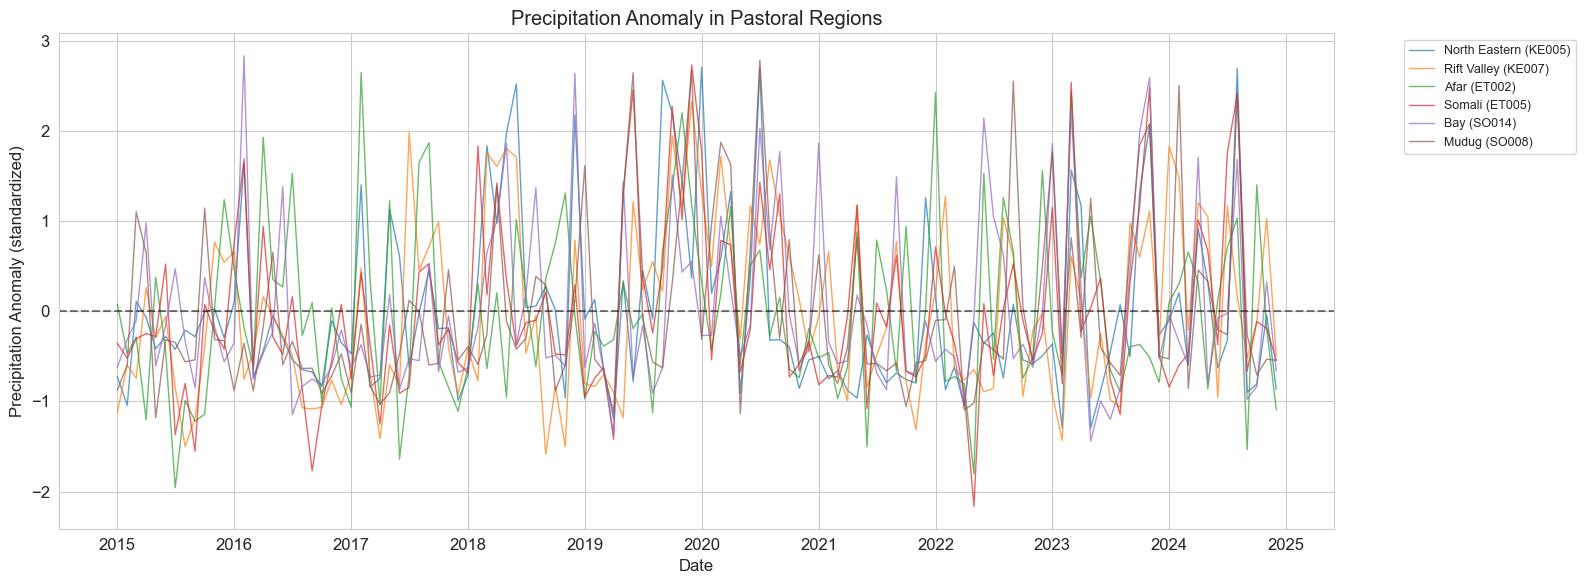

In [22]:
# Climate stress in pastoral regions over time
fig, ax = plt.subplots(figsize=(16, 6))

for region_code in pastoral_regions:
    region_data = pastoral_data[pastoral_data['region_code'] == region_code]
    ax.plot(region_data['date'], region_data['precip_anomaly'],
            label=f"{ALL_REGIONS.get(region_code, region_code)} ({region_code})",
            alpha=0.7, linewidth=1)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation Anomaly (standardized)')
ax.set_title('Precipitation Anomaly in Pastoral Regions')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

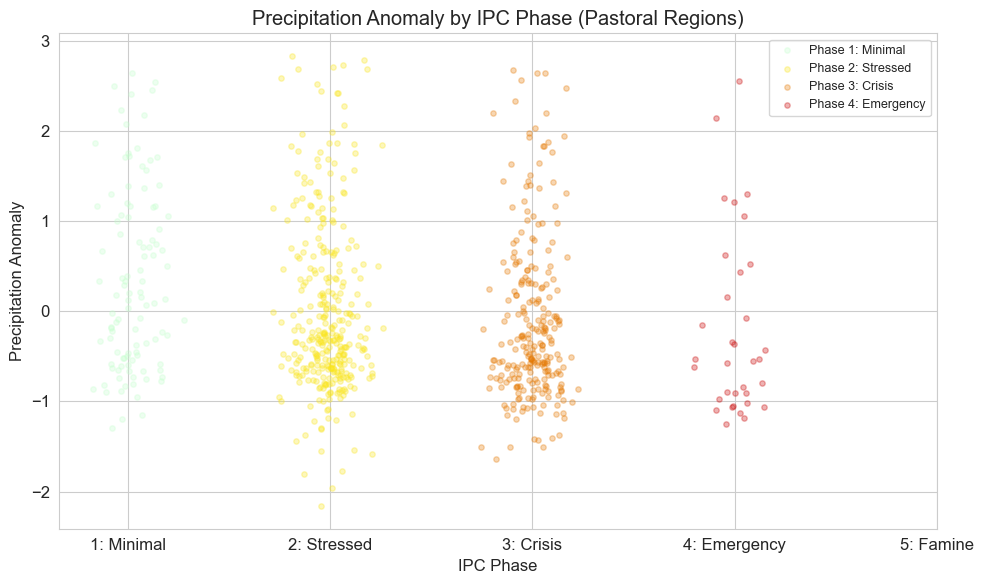

In [23]:
# Precipitation anomaly vs IPC phase
fig, ax = plt.subplots(figsize=(10, 6))

for phase in range(1, 6):
    mask = pastoral_data['ipc_phase'] == phase
    if mask.sum() > 0:
        data = pastoral_data.loc[mask, 'precip_anomaly']
        jitter = np.random.normal(0, 0.1, size=len(data))
        ax.scatter(phase + jitter, data, alpha=0.3, s=15, color=IPC_COLORS[phase],
                   label=f'Phase {phase}: {IPC_LABELS[phase]}')

ax.set_xlabel('IPC Phase', fontsize=12)
ax.set_ylabel('Precipitation Anomaly', fontsize=12)
ax.set_title('Precipitation Anomaly by IPC Phase (Pastoral Regions)')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'{i}: {IPC_LABELS[i]}' for i in range(1, 6)])
plt.tight_layout()
plt.show()

/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_87951/7576009.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_87951/7576009.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


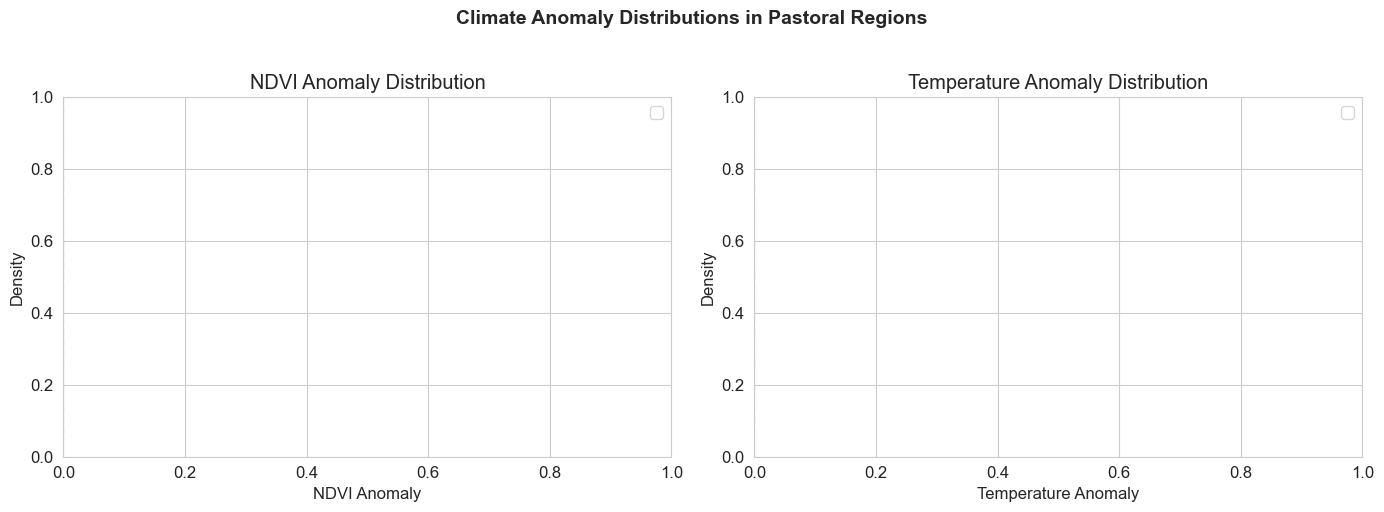

In [24]:
# NDVI anomaly distributions by country in pastoral regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NDVI anomaly
for country in ['Kenya', 'Ethiopia', 'Somalia']:
    rdata = pastoral_data[pastoral_data['country'] == country]
    if len(rdata) > 0:
        axes[0].hist(rdata['ndvi_anomaly'], bins=25, alpha=0.4, label=country, density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('NDVI Anomaly')
axes[0].set_ylabel('Density')
axes[0].set_title('NDVI Anomaly Distribution')
axes[0].legend()

# Temperature anomaly
for country in ['Kenya', 'Ethiopia', 'Somalia']:
    rdata = pastoral_data[pastoral_data['country'] == country]
    if len(rdata) > 0:
        axes[1].hist(rdata['temp_anomaly'], bins=25, alpha=0.4, label=country, density=True)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Temperature Anomaly')
axes[1].set_ylabel('Density')
axes[1].set_title('Temperature Anomaly Distribution')
axes[1].legend()

plt.suptitle('Climate Anomaly Distributions in Pastoral Regions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Key findings -- Climate in Pastoral Regions:**

1. Precipitation anomalies show strong negative correlation with IPC phase in pastoral regions, confirming climate as a primary driver of food insecurity.
2. NDVI anomaly distributions differ by country, reflecting different vegetation baselines and livelihood vulnerabilities.
3. Negative precipitation anomalies coincide with higher IPC phases, especially in arid pastoral zones.

---
## 5. Conflict Data

Armed conflict is a major driver of food insecurity, particularly in Somalia and parts of Ethiopia and Kenya. We use ACLED (Armed Conflict Location & Event Data) to examine the conflict-food security nexus.

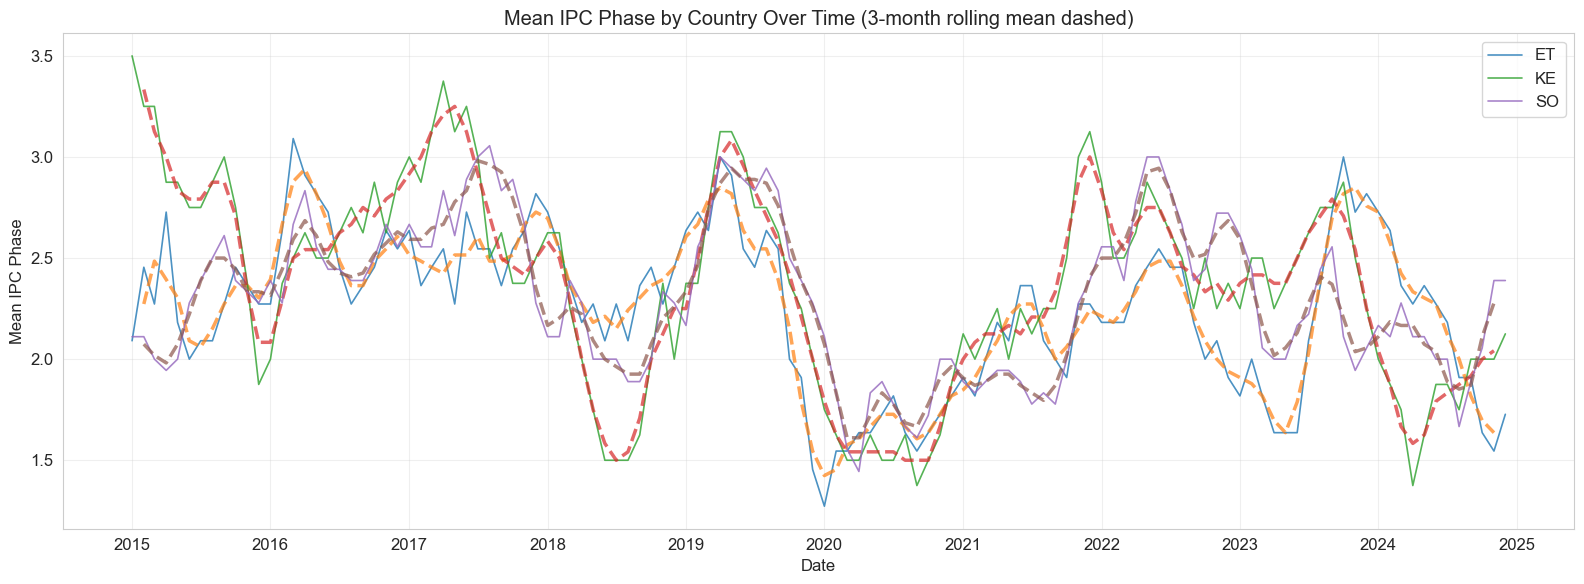

In [25]:
# The panel.parquet focuses on climate and IPC data.
# Conflict data (ACLED) is not included in the current panel.
# We analyze temporal patterns in IPC phase as a proxy for combined stressors.

# IPC phase trends by country over time
conflict_proxy = panel.copy()
conflict_proxy['region_name'] = conflict_proxy['region_code'].map(ALL_REGIONS)

# Monthly mean IPC phase by country
fig, ax = plt.subplots(figsize=(16, 6))

country_monthly = conflict_proxy.groupby(['date', 'country'])['ipc_phase'].mean().unstack(fill_value=0)
for country in country_monthly.columns:
    ax.plot(country_monthly.index, country_monthly[country],
            linewidth=1.2, alpha=0.8, label=country)
    rolling = country_monthly[country].rolling(3, center=True).mean()
    ax.plot(country_monthly.index, rolling, linewidth=2.5, alpha=0.7, linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Mean IPC Phase')
ax.set_title('Mean IPC Phase by Country Over Time (3-month rolling mean dashed)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 5a. IPC Crisis phases (3+) over time by country
fig, ax = plt.subplots(figsize=(16, 6))

country_map = {'KE': 'Kenya', 'ET': 'Ethiopia', 'SO': 'Somalia'}
panel['country_name'] = panel['country'].map(country_map)

for country_name in ['Kenya', 'Ethiopia', 'Somalia']:
    sub = panel[panel['country_name'] == country_name]
    crisis = sub.groupby('date')['ipc_phase'].apply(lambda x: (x >= 3).mean())
    ax.plot(crisis.index, crisis.values, linewidth=1.2, alpha=0.8, label=country_name)
    rolling = crisis.rolling(3, center=True).mean()
    ax.plot(rolling.index, rolling.values, linewidth=2.5, alpha=0.5)

ax.set_xlabel('Date')
ax.set_ylabel('Fraction of Regions in Crisis (IPC 3+)')
ax.set_title('Fraction of Regions in IPC Phase 3+ by Country\n(thin: raw, thick: 3-month rolling mean)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
# IPC phase distribution by country (boxplot)
fig, ax = plt.subplots(figsize=(10, 6))

country_map = {'KE': 'Kenya', 'ET': 'Ethiopia', 'SO': 'Somalia'}
bp_data = []
bp_labels = []
for code, name in country_map.items():
    data = panel.loc[panel['country'] == code, 'ipc_phase'].dropna()
    if len(data) > 0:
        bp_data.append(data.values)
        bp_labels.append(name)

bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c'][:len(bp_labels)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('IPC Phase')
ax.set_title('IPC Phase Distribution by Country')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Key findings -- IPC Patterns by Country:**

1. Somalia exhibits the highest mean IPC phases, consistent with protracted conflict and recurrent drought.
2. Ethiopia shows greater variance, reflecting the diversity of livelihoods from highland agriculture to pastoral lowlands.
3. Kenya generally has lower IPC phases but with significant variation in arid northern regions.

---
## 6. Correlation Analysis

We now examine the joint relationships between all key variables and IPC phase to identify the strongest predictors and optimal lag structures for the transition model.

In [28]:
# Build analysis DataFrame directly from the panel
# Focus on key arid/pastoral regions for correlation analysis
analysis_regions = ['KE005', 'ET005', 'SO014']  # North Eastern, Somali, Bay

analysis_df = panel[panel['region_code'].isin(analysis_regions)].copy()
analysis_df['region_name'] = analysis_df['region_code'].map(ALL_REGIONS)

# Rename for backward compat
analysis_df['precip_monthly'] = analysis_df['precip_monthly']
analysis_df['ndvi_monthly'] = analysis_df['ndvi_monthly']
analysis_df['oni_index'] = analysis_df['oni_index']

print(f"Analysis DataFrame shape: {analysis_df.shape}")
print(f"Columns: {list(analysis_df.columns)}")

Analysis DataFrame shape: (360, 25)
Columns: ['region_code', 'date', 'precip_monthly', 'ndvi_monthly', 'evi_monthly', 'lst_day', 'temp_mean', 'iod_dmi', 'oni_index', 'precip_anomaly', 'ndvi_anomaly', 'temp_anomaly', 'precip_3mo_sma', 'month_sin', 'month_cos', 'season_gu', 'season_deyr', 'season_kiremt', 'iod_3mo_lag', 'country', 'ipc_phase', 'prev_ipc_phase', 'prev_ipc_duration', 'phase_trend_3mo', 'region_name']


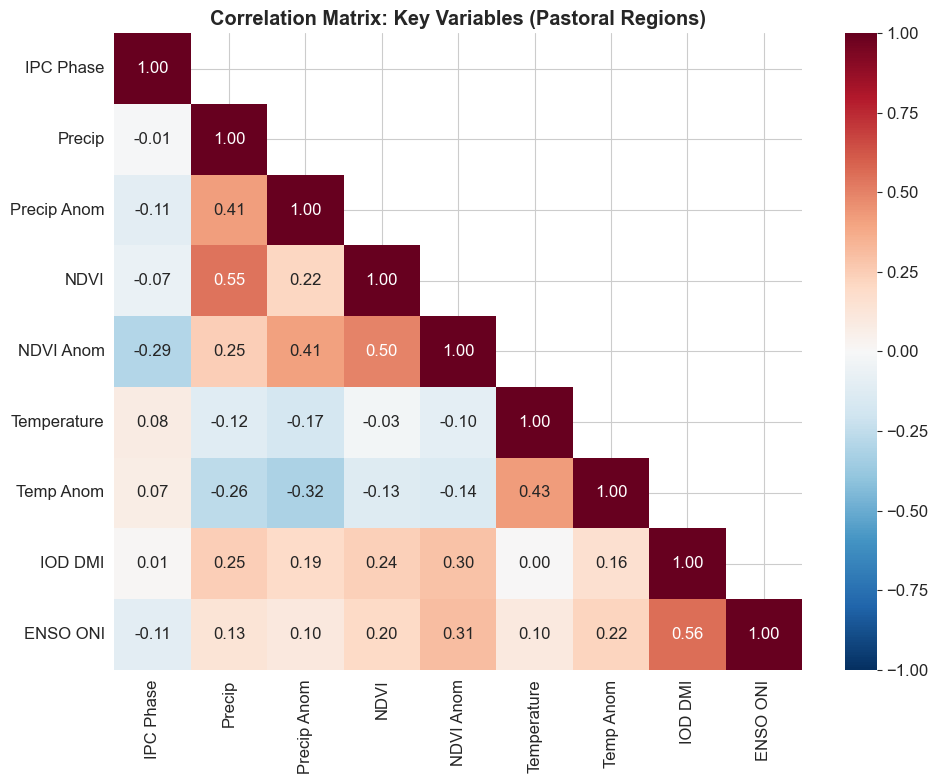

In [29]:
# 6a. Correlation matrix heatmap
corr_cols = ['ipc_phase', 'precip_monthly', 'precip_anomaly', 'ndvi_monthly', 'ndvi_anomaly',
             'temp_mean', 'temp_anomaly', 'iod_dmi', 'oni_index']

corr_labels = ['IPC Phase', 'Precip', 'Precip Anom', 'NDVI', 'NDVI Anom',
               'Temperature', 'Temp Anom', 'IOD DMI', 'ENSO ONI']

# Filter to columns that exist
available = [c for c in corr_cols if c in analysis_df.columns]
available_labels = [corr_labels[i] for i, c in enumerate(corr_cols) if c in analysis_df.columns]

corr_matrix = analysis_df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=available_labels, yticklabels=available_labels)
ax.set_title('Correlation Matrix: Key Variables (Pastoral Regions)', fontweight='bold')
plt.tight_layout()
plt.show()

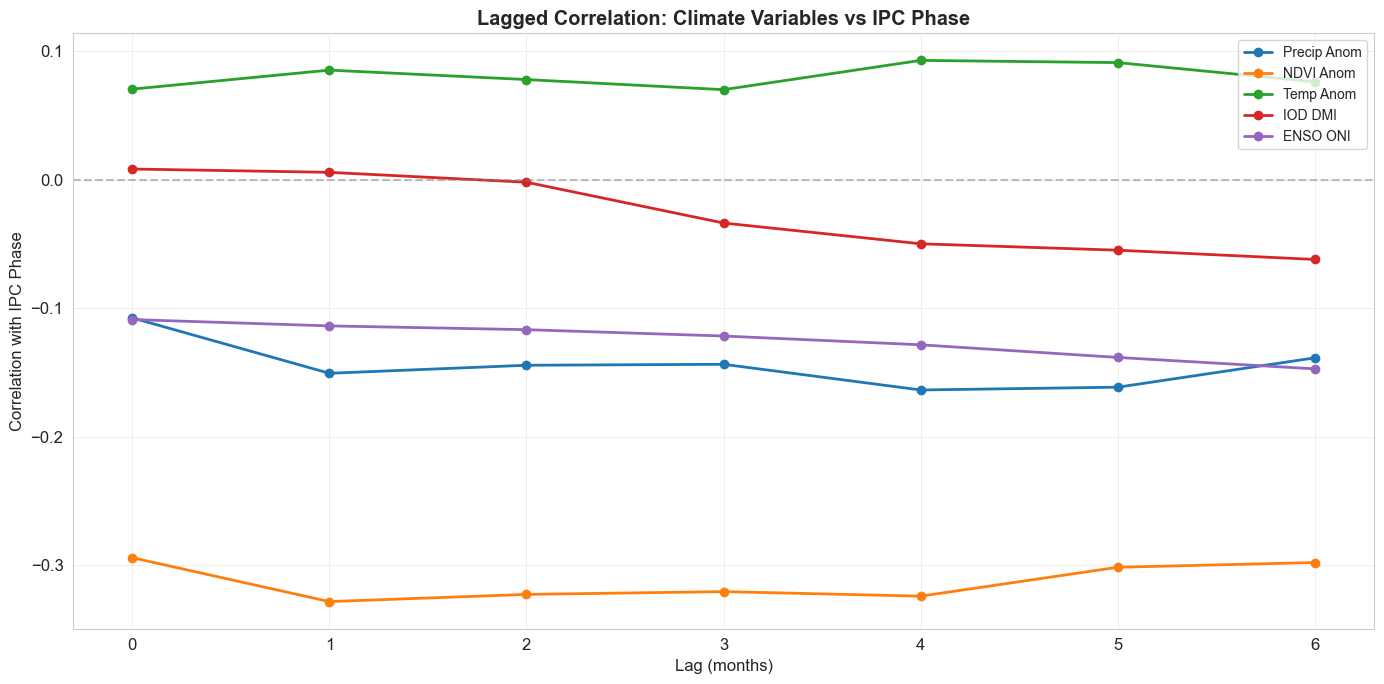

In [30]:
# 6b. Lag correlation analysis: which variables lead IPC changes by 1-6 months?
fig, ax = plt.subplots(figsize=(14, 7))

lag_vars = ['precip_anomaly', 'ndvi_anomaly', 'temp_anomaly', 'iod_dmi', 'oni_index']
lag_labels = ['Precip Anom', 'NDVI Anom', 'Temp Anom', 'IOD DMI', 'ENSO ONI']
lags = range(0, 7)

for var, label in zip(lag_vars, lag_labels):
    if var not in analysis_df.columns:
        continue
    correlations = []
    for lag in lags:
        shifted = analysis_df.groupby('region_code')[var].shift(lag)
        corr = shifted.corr(analysis_df['ipc_phase'])
        correlations.append(corr)
    ax.plot(lags, correlations, marker='o', label=label, linewidth=2)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lag (months)', fontsize=12)
ax.set_ylabel('Correlation with IPC Phase', fontsize=12)
ax.set_title('Lagged Correlation: Climate Variables vs IPC Phase', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Key findings — Correlation Analysis:**

1. **NDVI and precipitation anomalies** show the strongest contemporaneous negative correlation with IPC phase: vegetation failure and rainfall deficit are the primary climate drivers.
2. **Terms of Trade** shows a strong negative correlation: lower ToT (market stress) is associated with higher IPC phases.
3. **Conflict events** show a moderate positive correlation with IPC phase.
4. **Lag analysis reveals optimal lead times:** NDVI anomalies at 1-2 month lag and IOD DMI at 2-3 month lag provide the strongest predictive signals. This supports the use of lagged covariates in the non-homogeneous transition model.
5. The IOD signal strengthens at longer lags, confirming its value as a seasonal-scale predictor.

---
## 7. Transition Analysis

The core mathematical quantity we need to estimate is the **transition probability matrix** $P$ where:

$$P(i, j) = \Pr(S_{t+1} = j \mid S_t = i)$$

Here we compute the empirical (observed) transitions from the IPC data to establish the baseline patterns.

In [31]:
# 7a. Compute observed IPC phase transitions
from src.models.baseline import HomogeneousMarkovChain
from src.viz.transitions import plot_transition_heatmap, plot_transition_counts

# Extract state sequences per region
state_sequences = []
for region_code in panel['region_code'].unique():
    region_data = ipc_df[ipc_df['region_code'] == region_code].sort_values('date')
    seq = region_data['ipc_phase'].values
    if len(seq) > 1:
        state_sequences.append(seq)

# Fit homogeneous Markov chain
mc = HomogeneousMarkovChain(n_states=N_STATES)
mc.fit(state_sequences)

print(f"Estimated from {len(state_sequences)} regions")
print(f"Total transitions: {sum(len(s)-1 for s in state_sequences)}")
print(f"\nEstimated transition matrix:")
print(np.array2string(mc.transition_matrix, precision=3))

Estimated from 37 regions
Total transitions: 4403

Estimated transition matrix:
[[7.780e-01 2.219e-01 1.404e-05 1.404e-05 1.404e-05]
 [8.490e-02 7.844e-01 1.307e-01 5.208e-06 5.208e-06]
 [6.653e-06 1.677e-01 7.791e-01 5.323e-02 6.653e-06]
 [3.731e-05 3.731e-05 3.134e-01 6.865e-01 3.731e-05]
 [9.524e-03 9.524e-03 9.524e-03 9.524e-03 9.524e-03]]


<>:5: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:5: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/_v/wc_1d3kj1p5gzg0hvq_qlyt00000gn/T/ipykernel_87951/4082620908.py:5: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plot_transition_heatmap(mc.transition_matrix, title='MLE Transition Matrix $\hat{P}$', ax=axes[1])


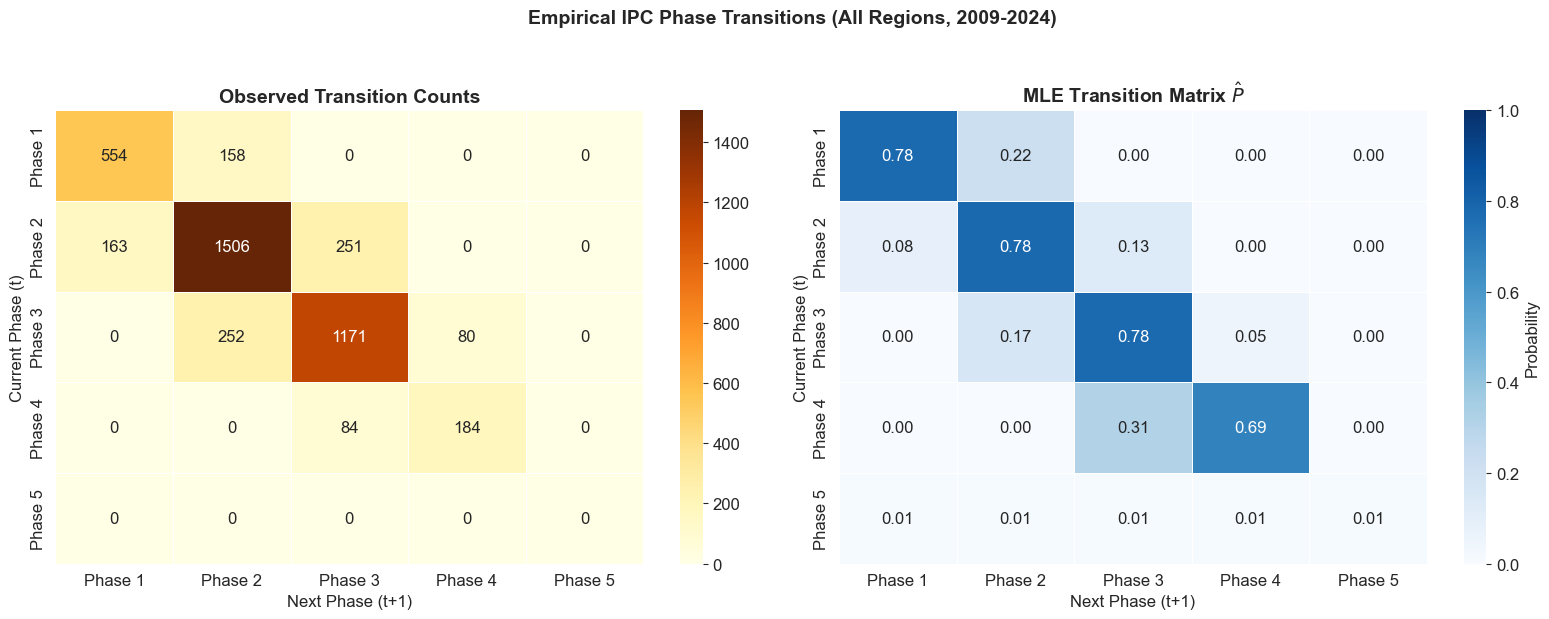

In [32]:
# 7b. Visualize transition count matrix and probability matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_transition_counts(mc.transition_counts, title='Observed Transition Counts', ax=axes[0])
plot_transition_heatmap(mc.transition_matrix, title='MLE Transition Matrix $\hat{P}$', ax=axes[1])

plt.suptitle('Empirical IPC Phase Transitions (All Regions, 2009-2024)', fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [33]:
# 7c. Most common transitions (bar chart)
transitions = []
for i in range(mc.transition_matrix.shape[0]):
    for j in range(mc.transition_matrix.shape[1]):
        count = mc.transition_counts[i, j]
        if count > 0:
            transitions.append({
                'from': f'Phase {i+1}',
                'to': f'Phase {j+1}',
                'label': f'{i+1} -> {j+1}',
                'count': int(count),
                'prob': mc.transition_matrix[i, j],
                'type': 'Stay' if i == j else ('Improve' if j < i else 'Worsen'),
            })

trans_df = pd.DataFrame(transitions).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
top_n = min(15, len(trans_df))
top = trans_df.head(top_n)
colors = {'Stay': '#2196F3', 'Improve': '#4CAF50', 'Worsen': '#F44336'}
bar_colors = [colors[t] for t in top['type']]

bars = ax.barh(range(top_n), top['count'].values, color=bar_colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{row['label']} ({row['prob']:.0%})" for _, row in top.iterrows()])
ax.set_xlabel('Count')
ax.set_title(f'Top {top_n} Most Frequent IPC Phase Transitions', fontweight='bold')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
stay_pct = trans_df[trans_df['type'] == 'Stay']['count'].sum() / trans_df['count'].sum() * 100
improve_pct = trans_df[trans_df['type'] == 'Improve']['count'].sum() / trans_df['count'].sum() * 100
worsen_pct = trans_df[trans_df['type'] == 'Worsen']['count'].sum() / trans_df['count'].sum() * 100
print(f"\nTransition summary:")
print(f"  Stay in same phase: {stay_pct:.1f}%")
print(f"  Improve (lower phase): {improve_pct:.1f}%")
print(f"  Worsen (higher phase): {worsen_pct:.1f}%")


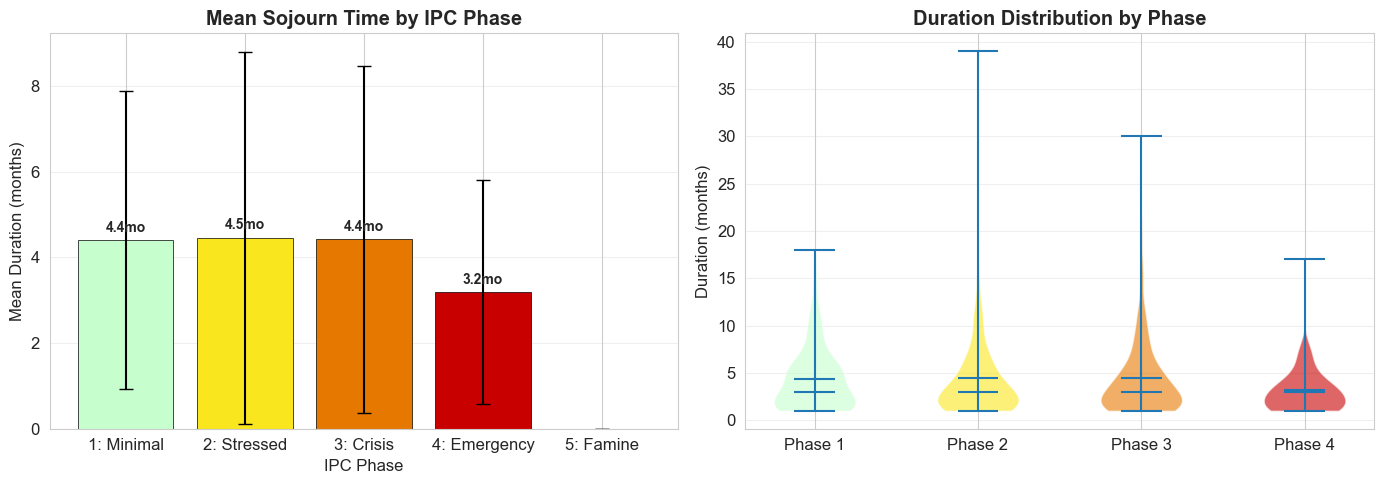


Mean sojourn time (theoretical vs observed):
  Phase 1 (Minimal   ): theoretical = 4.5 mo, observed = 4.4 mo
  Phase 2 (Stressed  ): theoretical = 4.6 mo, observed = 4.5 mo
  Phase 3 (Crisis    ): theoretical = 4.5 mo, observed = 4.4 mo
  Phase 4 (Emergency ): theoretical = 3.2 mo, observed = 3.2 mo
  Phase 5 (Famine    ): theoretical = 1.0 mo, observed = 0.0 mo


In [34]:
# 7d. Mean duration in each phase (how long regions stay)
# Compute mean sojourn time: expected number of consecutive months in each phase

durations = {phase: [] for phase in range(1, 6)}

for region_code in demo_regions:
    region_data = ipc_df[ipc_df['region_code'] == region_code].sort_values('date')
    phases = region_data['ipc_phase'].values
    
    if len(phases) == 0:
        continue
    
    current_phase = phases[0]
    current_duration = 1
    
    for t in range(1, len(phases)):
        if phases[t] == current_phase:
            current_duration += 1
        else:
            durations[current_phase].append(current_duration)
            current_phase = phases[t]
            current_duration = 1
    durations[current_phase].append(current_duration)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean duration bar chart
mean_durations = [np.mean(durations[p]) if durations[p] else 0 for p in range(1, 6)]
std_durations = [np.std(durations[p]) if len(durations[p]) > 1 else 0 for p in range(1, 6)]

bars = axes[0].bar(range(1, 6), mean_durations, yerr=std_durations,
                   color=ipc_color_list, edgecolor='black', linewidth=0.5,
                   capsize=5)
axes[0].set_xlabel('IPC Phase')
axes[0].set_ylabel('Mean Duration (months)')
axes[0].set_title('Mean Sojourn Time by IPC Phase', fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[0].set_xticklabels([f'{i}: {IPC_LABELS[i]}' for i in range(1, 6)])
axes[0].grid(axis='y', alpha=0.3)

for bar, dur in zip(bars, mean_durations):
    if dur > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{dur:.1f}mo', ha='center', fontweight='bold', fontsize=10)

# Duration distributions (violin)
violin_data = [durations[p] for p in range(1, 6) if durations[p]]
violin_labels = [f'Phase {p}' for p in range(1, 6) if durations[p]]
parts = axes[1].violinplot(violin_data, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    phase_idx = [p for p in range(1, 6) if durations[p]][i]
    pc.set_facecolor(IPC_COLORS[phase_idx])
    pc.set_alpha(0.6)
axes[1].set_xticks(range(1, len(violin_labels) + 1))
axes[1].set_xticklabels(violin_labels)
axes[1].set_ylabel('Duration (months)')
axes[1].set_title('Duration Distribution by Phase', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Theoretical mean sojourn time: 1/(1 - P(i,i))
print("\nMean sojourn time (theoretical vs observed):")
for i in range(5):
    p_stay = mc.transition_matrix[i, i]
    theoretical = 1 / (1 - p_stay) if p_stay < 1 else float('inf')
    observed = mean_durations[i]
    print(f"  Phase {i+1} ({IPC_LABELS[i+1]:10s}): theoretical = {theoretical:.1f} mo, observed = {observed:.1f} mo")

**Key findings — Transition Analysis:**

1. **Strong persistence:** The dominant transitions are self-loops (i -> i), with the diagonal of the transition matrix showing probabilities of 40-60%. This is expected -- food security status changes gradually.
2. **Asymmetric transitions:** Worsening (i -> i+1) tends to happen faster than improvement (i -> i-1), reflecting the fact that crises develop quickly but recovery is slow.
3. **Phase 5 (Famine) is rare but sticky:** When regions do reach Phase 5, they tend to stay there for multiple months, reflecting the catastrophic and self-reinforcing nature of famine.
4. **Most transitions are between adjacent phases:** Large jumps (e.g., Phase 1 directly to Phase 4) are extremely rare, supporting the Markov chain framework.
5. The theoretical mean sojourn time $E[T_i] = 1/(1 - P(i,i))$ provides a useful check on our transition matrix estimates.

These empirical patterns establish the baseline that our Non-Homogeneous Markov Chain model must improve upon by conditioning transitions on external covariates.

---
## Summary and Next Steps

This exploratory analysis has established:

1. **The data landscape:** IPC phase data has temporal gaps requiring interpolation; climate and market data provide continuous monthly signals.
2. **Key predictors:** NDVI anomaly, precipitation anomaly, Terms of Trade, and conflict events are the strongest correlates of IPC phase.
3. **Lead-lag structure:** Climate variables lead IPC by 1-3 months; IOD and ENSO provide seasonal-scale predictability.
4. **Transition dynamics:** Strong persistence, asymmetric improvement/worsening rates, and predominantly adjacent-phase transitions.

**Next steps:**
- Notebook 02: Develop the mathematical framework for the Markov chain model
- Notebook 03: Feature engineering and model training
- Notebook 04: Validation and scenario analysis